In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Generating the synthetic dataset

In [50]:
np.random.seed(42)

n_samples = 10000

temperature = np.random.normal(loc=350, scale=15, size=n_samples)
pressure = np.random.normal(loc=8, scale=1.5, size=n_samples)
flow_rate = np.random.normal(loc=120, scale=20, size=n_samples)
level = np.random.uniform(40, 90, size=n_samples)
vibration = np.random.normal(3.2, 0.5, size=n_samples)
humidity = np.random.normal(40, 10, size=n_samples)

def hazop_risk(temp, press):
    if temp > 380 and press > 10:
        return "High"
    elif temp > 365 or press > 9:
        return "Medium"
    else:
        return "Low"

risk_label = [hazop_risk(t, p) for t, p in zip(temperature, pressure)]

df = pd.DataFrame({
    "Temperature": temperature,
    "Pressure": pressure,
    "FlowRate": flow_rate,
    "Level": level,
    "Vibration": vibration,
    "Humidity": humidity,
    "Risk": risk_label
})

df.to_csv("synthetic_refinery_data.csv", index=False)

print(df)

      Temperature   Pressure    FlowRate      Level  Vibration   Humidity  \
0      357.450712   6.982258  126.965725  81.593431   3.549302  28.457718   
1      347.926035   7.541751  125.666472  84.082188   3.332515  38.125996   
2      359.715328   7.103928  101.269603  61.662521   2.229165  44.430478   
3      372.845448   8.165627  131.591684  58.734401   2.998401  52.061356   
4      346.487699   9.795768   90.198346  70.634947   3.131918  32.150132   
...           ...        ...         ...        ...        ...        ...   
9995   369.516531   8.581741  108.454243  70.792859   3.000681  35.613717   
9996   320.024825  10.066050  148.892080  77.013456   3.535987  37.310478   
9997   339.420249   8.567531  109.972654  52.729247   4.058597  31.745542   
9998   357.436484  10.570295   82.152864  54.969995   3.616551  55.257474   
9999   359.665827   5.570120  115.422316  72.014696   2.598987  20.700687   

        Risk  
0        Low  
1        Low  
2        Low  
3     Medium  


Full Preprocessing and Feature Engineering

In [51]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [52]:
# Load data
df = pd.read_csv("synthetic_refinery_data.csv")

print("Raw Data Overview:")
print(df.head())
print(df.describe())

Raw Data Overview:
   Temperature  Pressure    FlowRate      Level  Vibration   Humidity    Risk
0   357.450712  6.982258  126.965725  81.593431   3.549302  28.457718     Low
1   347.926035  7.541751  125.666472  84.082188   3.332515  38.125996     Low
2   359.715328  7.103928  101.269603  61.662521   2.229165  44.430478     Low
3   372.845448  8.165627  131.591684  58.734401   2.998401  52.061356  Medium
4   346.487699  9.795768   90.198346  70.634947   3.131918  32.150132  Medium
        Temperature      Pressure      FlowRate         Level     Vibration  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean     349.967960      8.020301    119.750745     64.946938      3.203917   
std       15.051936      1.501515     19.828363     14.517841      0.497427   
min      291.163996      2.215437     46.898270     40.000837      1.052305   
25%      339.911142      7.006984    105.996962     52.294101      2.867901   
50%      349.961075      8.023770    11

In [53]:
# Handle missing values
# (synthetic data normally has no missing values but we add it for completeness)
df = df.fillna(df.median(numeric_only=True))

In [54]:
# Remove outliers (IQR method)
def remove_outliers_iqr(data, cols):
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data = data[(data[col] >= lower) & (data[col] <= upper)]
    return data

numeric_cols = ["Temperature", "Pressure", "FlowRate", "Level", "Vibration", "Humidity"]
df = remove_outliers_iqr(df, numeric_cols)

print("After Outlier Removal:", df.shape)


After Outlier Removal: (9664, 7)


In [55]:
# Feature engineering
# A. Interaction Features
df["Temp_Pressure_Ratio"] = df["Temperature"] / df["Pressure"]
df["Flow_Per_Level"] = df["FlowRate"] / df["Level"]

# B. Polynomial Features
df["Temp_squared"] = df["Temperature"] ** 2
df["Pressure_squared"] = df["Pressure"] ** 2

# C. Statistical Features
df["Temp_RollingMean"] = df["Temperature"].rolling(window=50, min_periods=1).mean()
df["Pressure_RollingStd"] = df["Pressure"].rolling(window=50, min_periods=1).std()

# D. Domain‑specific Features
df["Stress_Index"] = (
    (df["Temperature"] / df["Temperature"].mean()) * 
    (df["Pressure"] / df["Pressure"].mean()) *
    df["Vibration"]
)

In [56]:
# Encode target lables
label_encoder = LabelEncoder()
df["RiskEncoded"] = label_encoder.fit_transform(df["Risk"])  
# Low=1, Medium=2, High=0 (depending on sorting)

print("Label Encoding Mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Label Encoding Mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [57]:
# Feature normalization 
scaler = StandardScaler()

scaled_columns = scaler.fit_transform(df[numeric_cols])
scaled_df = pd.DataFrame(scaled_columns, columns=[col+"_scaled" for col in numeric_cols])

df = pd.concat([df.reset_index(drop=True), scaled_df], axis=1)

In [58]:
# Save final processed dataset
df.to_csv("processed_refinery_data.csv", index=False)
print("Processed dataset saved as processed_refinery_data.csv")

print(df)

Processed dataset saved as processed_refinery_data.csv
      Temperature   Pressure    FlowRate      Level  Vibration   Humidity  \
0      357.450712   6.982258  126.965725  81.593431   3.549302  28.457718   
1      347.926035   7.541751  125.666472  84.082188   3.332515  38.125996   
2      359.715328   7.103928  101.269603  61.662521   2.229165  44.430478   
3      372.845448   8.165627  131.591684  58.734401   2.998401  52.061356   
4      346.487699   9.795768   90.198346  70.634947   3.131918  32.150132   
...           ...        ...         ...        ...        ...        ...   
9659   369.516531   8.581741  108.454243  70.792859   3.000681  35.613717   
9660   320.024825  10.066050  148.892080  77.013456   3.535987  37.310478   
9661   339.420249   8.567531  109.972654  52.729247   4.058597  31.745542   
9662   357.436484  10.570295   82.152864  54.969995   3.616551  55.257474   
9663   359.665827   5.570120  115.422316  72.014696   2.598987  20.700687   

        Risk  Temp_P

Full XGBoost Training and Evaluation

In [72]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import pickle
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
# Load processed dataset
df = pd.read_csv("processed_refinery_data.csv")

In [74]:
# Select feature
# Use both original and engineered + scaled features
feature_cols = [
    "Temperature_scaled",
    "Pressure_scaled",
    "FlowRate_scaled",
    "Level_scaled",
    "Vibration_scaled",
    "Humidity_scaled",
    
    # engineered features
    "Temp_Pressure_Ratio",
    "Flow_Per_Level",
    "Temp_squared",
    "Pressure_squared",
    "Temp_RollingMean",
    "Pressure_RollingStd",
    "Stress_Index"
]

X = df[feature_cols]
y = df["RiskEncoded"]


In [75]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


In [77]:
!pip install mlflow

  Using cached click-8.3.3-py3-none-any.whl.metadata (2.6 kB)
  Using cached fastapi-0.136.1-py3-none-any.whl.metadata (28 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached uvicorn-0.46.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached idna-3.13-py3-none-any.whl.metadata (8.0 kB)
  Using cached certifi-2026.4.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using

  You can safely remove it manually.

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [78]:
# MLflow experiment setup
import mlflow
import mlflow.xgboost

mlflow.set_experiment("Refinery_Risk_Classification")

with mlflow.start_run():
# Train XGBoost model
    model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.8,
    eval_metric="mlogloss"
)

    model.fit(X_train, y_train)

# Predictions
    y_pred = model.predict(X_test)

# Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)

    print("=== Model Performance ===")
    print("Accuracy: ", accuracy)
    print("Precision: ", precision)
    print("Recall: ", recall)
    print("F1 Score: ", f1)

    print("\n===== Classification Report =====")
    print(classification_report(y_test, y_pred, target_names=["High", "Low", "Medium"]))

# log parameters
    mlflow.log_params({
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.08,
        "subsample": 0.9,
        "colsample_bytree": 0.8
    })

    mlflow.log_param("feature_count", len(feature_cols))

# Log metrics
    mlflow.log_metrics({
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

# Log feature columns
    with open("feature_columns.pkl", "wb") as f:
        pickle.dump(feature_cols, f)
    mlflow.log_artifact("feature_columns.pkl")

# Log model into MLflow
    mlflow.xgboost.log_model(model, artifact_path="xgb_model")

    print("\nXGBoost model logged into MLflow successfully!")

2026/05/07 18:07:16 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/07 18:07:16 INFO mlflow.store.db.utils: Updating database tables
2026/05/07 18:07:17 INFO mlflow.tracking.fluent: Experiment with name 'Refinery_Risk_Classification' does not exist. Creating a new experiment.
2026/05/07 18:07:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== Model Performance ===
Accuracy:  0.999482669425763
Precision:  0.9994830973253281
Recall:  0.999482669425763
F1 Score:  0.9994825971896903

===== Classification Report =====
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         3
         Low       1.00      1.00      1.00      1208
      Medium       1.00      1.00      1.00       722

    accuracy                           1.00      1933
   macro avg       1.00      1.00      1.00      1933
weighted avg       1.00      1.00      1.00      1933


XGBoost model logged into MLflow successfully!


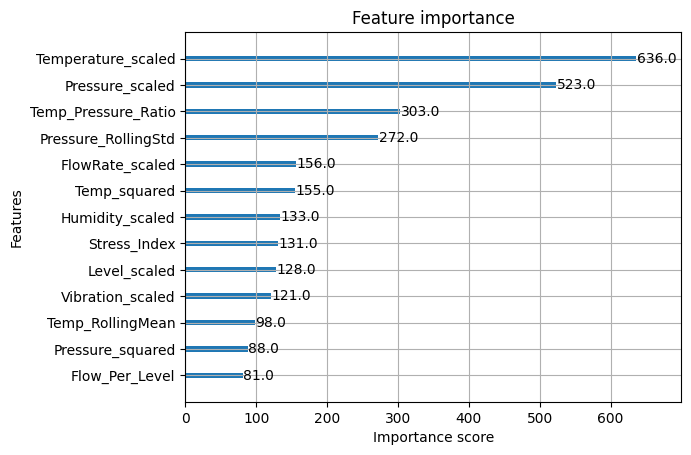

In [79]:
import matplotlib.pyplot as plt

xgb.plot_importance(model)
plt.show()

In [80]:
from collections import Counter

print(Counter(y_encoded))

Counter({np.int64(1): 6214, np.int64(2): 3769, np.int64(0): 17})
